In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


In [3]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)

test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Train:", len(train_data), "Test:", len(test_data))


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.2MB/s]

Train: 60000 Test: 10000


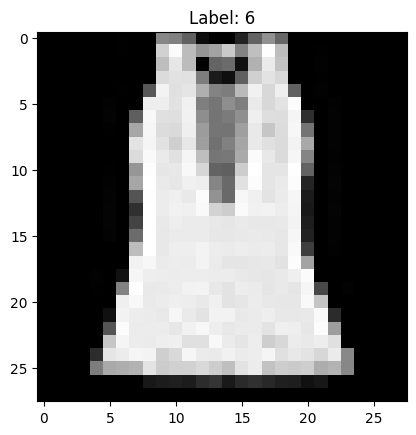

In [4]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.show()


In [5]:
class DeepFeedForward(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Flatten
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        x = self.fc4(x)  # Linear output
        return x


In [6]:
model = DeepFeedForward().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10


In [7]:
def train(model, train_loader, criterion, optimizer, epochs):
    model.train()

    for epoch in range(epochs):
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

            # Accuracy
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss/len(train_loader):.4f} "
              f"Train Acc: {100*correct/total:.2f}%")


In [8]:
train(model, train_loader, criterion, optimizer, epochs)


Epoch [1/10] Loss: 0.5173 Train Acc: 81.06%
Epoch [2/10] Loss: 0.3757 Train Acc: 86.13%
Epoch [3/10] Loss: 0.3407 Train Acc: 87.39%
Epoch [4/10] Loss: 0.3143 Train Acc: 88.32%
Epoch [5/10] Loss: 0.2962 Train Acc: 89.00%
Epoch [6/10] Loss: 0.2786 Train Acc: 89.64%
Epoch [7/10] Loss: 0.2626 Train Acc: 90.22%
Epoch [8/10] Loss: 0.2529 Train Acc: 90.44%
Epoch [9/10] Loss: 0.2391 Train Acc: 91.08%
Epoch [10/10] Loss: 0.2299 Train Acc: 91.36%


In [10]:
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    print(f" Test Accuracy: {acc:.2f}%")
    return acc

test(model, test_loader)


 Test Accuracy: 88.42%


88.42

* Forward pass

Input → flattened into 784 vector

passes through hidden layers

output gives logits (raw class scores)

* Loss

CrossEntropyLoss compares logits with true label

tells how wrong the model is

* Backward pass

loss.backward() computes gradients for every weight

Gradient update

optimizer (Adam/SGD) adjusts weights to reduce loss

In [11]:
# Depth & Width Experiments (1 / 3 / 5 layers)
class FlexibleFFNN(nn.Module):
    def __init__(self, hidden_sizes=[256,128,64], activation="relu"):
        super().__init__()
        act_layer = nn.ReLU() if activation=="relu" else nn.Tanh()

        layers = []
        prev = 784

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(act_layer)
            prev = h

        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


In [13]:
configs = {
    "1-layer (256)": [256],
    "3-layer (256-128-64)": [256,128,64],
    "5-layer (512-256-128-64-32)": [512,256,128,64,32]
}

results = {}

for name, hs in configs.items():
    print("\n==============================")
    print("Training:", name)

    model = FlexibleFFNN(hidden_sizes=hs, activation="relu").to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train(model, train_loader, criterion, optimizer, epochs=5)
    acc = test(model, test_loader)

    results[name] = acc

print("\n=== Final Comparison ===")
for k,v in results.items():
    print(k, "->", f"{v:.2f}%")



Training: 1-layer (256)
Epoch [1/5] Loss: 0.4850 Train Acc: 82.48%
Epoch [2/5] Loss: 0.3682 Train Acc: 86.41%
Epoch [3/5] Loss: 0.3370 Train Acc: 87.55%
Epoch [4/5] Loss: 0.3099 Train Acc: 88.61%
Epoch [5/5] Loss: 0.2896 Train Acc: 89.35%
 Test Accuracy: 86.96%

Training: 3-layer (256-128-64)
Epoch [1/5] Loss: 0.5217 Train Acc: 81.10%
Epoch [2/5] Loss: 0.3774 Train Acc: 86.08%
Epoch [3/5] Loss: 0.3395 Train Acc: 87.59%
Epoch [4/5] Loss: 0.3129 Train Acc: 88.42%
Epoch [5/5] Loss: 0.2919 Train Acc: 89.22%
 Test Accuracy: 87.98%

Training: 5-layer (512-256-128-64-32)
Epoch [1/5] Loss: 0.5758 Train Acc: 78.74%
Epoch [2/5] Loss: 0.3994 Train Acc: 85.46%
Epoch [3/5] Loss: 0.3562 Train Acc: 86.93%
Epoch [4/5] Loss: 0.3318 Train Acc: 87.76%
Epoch [5/5] Loss: 0.3101 Train Acc: 88.70%
 Test Accuracy: 87.47%

=== Final Comparison ===
1-layer (256) -> 86.96%
3-layer (256-128-64) -> 87.98%
5-layer (512-256-128-64-32) -> 87.47%


deeper nets learn better features

too deep may overfit and train slower

In [17]:
# Activation Study (ReLU vs Sigmoid vs Tanh vs LeakyReLU)
def get_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    elif name == "sigmoid":
        return nn.Sigmoid()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "leakyrelu":
        return nn.LeakyReLU(0.01)
    else:
        raise ValueError("Unknown activation")


In [15]:
class ActivationNet(nn.Module):
    def __init__(self, hidden_sizes=[256,128,64], activation="relu"):
        super().__init__()
        act = get_activation(activation)

        layers = []
        prev = 784
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(act)
            prev = h

        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


In [16]:
activations = ["relu", "sigmoid", "tanh", "leakyrelu"]
act_results = {}

for act in activations:
    print("\n==============================")
    print("Activation:", act)

    model = ActivationNet(activation=act).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train(model, train_loader, criterion, optimizer, epochs=5)
    acc = test(model, test_loader)

    act_results[act] = acc

print("\n=== Activation Comparison ===")
for k,v in act_results.items():
    print(k, "->", f"{v:.2f}%")



Activation: relu
Epoch [1/5] Loss: 0.5143 Train Acc: 81.35%
Epoch [2/5] Loss: 0.3779 Train Acc: 86.10%
Epoch [3/5] Loss: 0.3361 Train Acc: 87.53%
Epoch [4/5] Loss: 0.3117 Train Acc: 88.56%
Epoch [5/5] Loss: 0.2875 Train Acc: 89.38%
 Test Accuracy: 87.46%

Activation: sigmoid
Epoch [1/5] Loss: 0.9043 Train Acc: 66.83%
Epoch [2/5] Loss: 0.4541 Train Acc: 84.23%
Epoch [3/5] Loss: 0.3856 Train Acc: 86.40%
Epoch [4/5] Loss: 0.3482 Train Acc: 87.77%
Epoch [5/5] Loss: 0.3236 Train Acc: 88.39%
 Test Accuracy: 86.41%

Activation: tanh
Epoch [1/5] Loss: 0.5145 Train Acc: 82.05%
Epoch [2/5] Loss: 0.3866 Train Acc: 85.94%
Epoch [3/5] Loss: 0.3540 Train Acc: 87.08%
Epoch [4/5] Loss: 0.3300 Train Acc: 88.00%
Epoch [5/5] Loss: 0.3175 Train Acc: 88.36%
 Test Accuracy: 86.02%

Activation: leakyrelu
Epoch [1/5] Loss: 0.5157 Train Acc: 80.99%
Epoch [2/5] Loss: 0.3766 Train Acc: 86.14%
Epoch [3/5] Loss: 0.3358 Train Acc: 87.60%
Epoch [4/5] Loss: 0.3097 Train Acc: 88.51%
Epoch [5/5] Loss: 0.2906 Train Acc

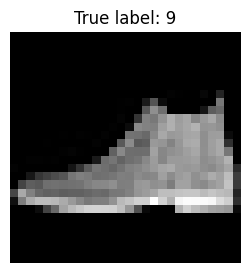

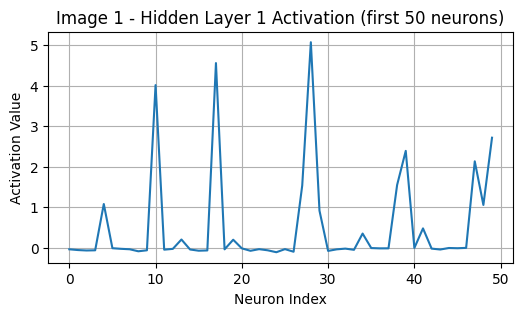

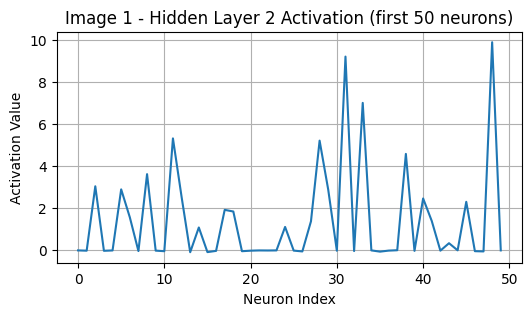

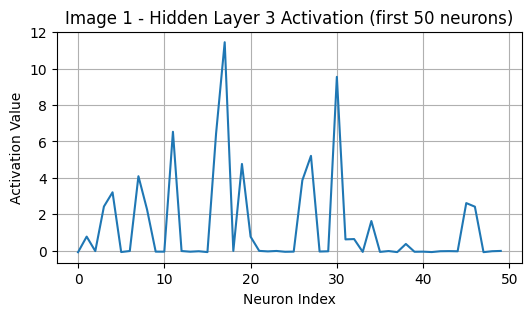

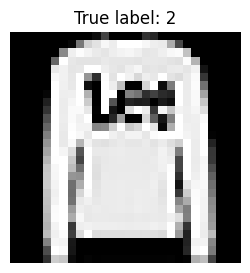

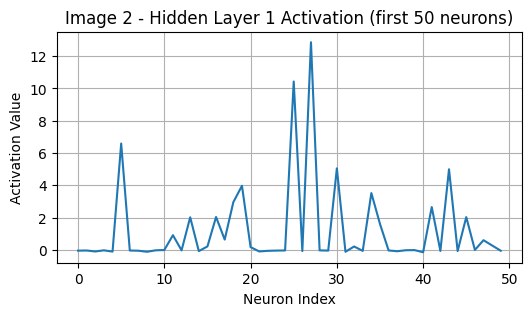

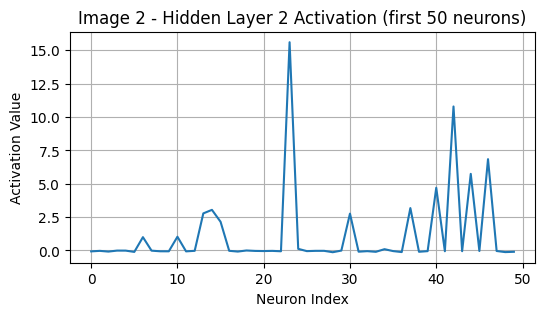

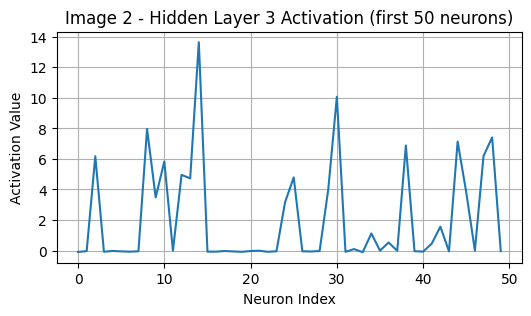

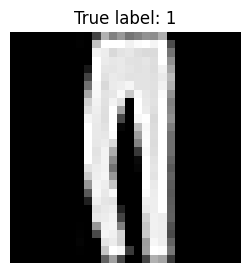

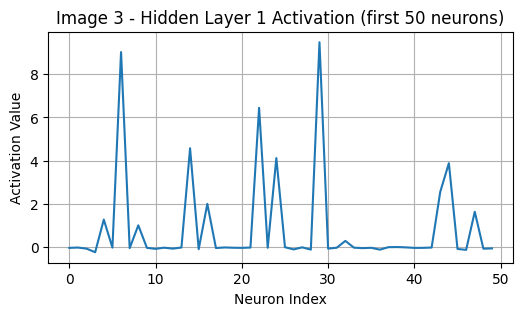

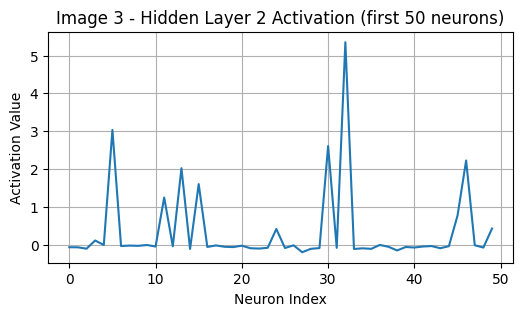

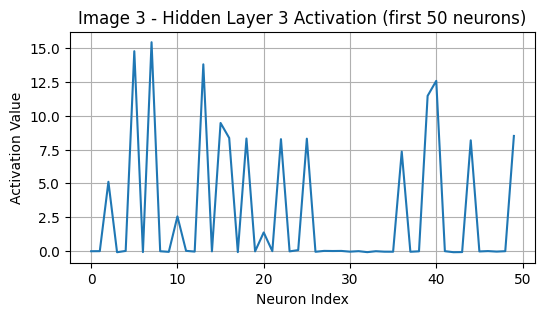

In [21]:
import torch.nn as nn
import matplotlib.pyplot as plt

# Visualize Hidden Layer Activations
def capture_activations(model, image):
    model.eval()
    x = image.to(device).unsqueeze(0)   # add batch dim
    x = x.view(1, -1)                   # flatten

    activations = []
    current = x

    with torch.no_grad():
        for layer in model.net:
            current = layer(current)
            if isinstance(layer, (nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU)):
                activations.append(current.detach().cpu())

    return activations


# Show activations for multiple images
images, labels = next(iter(test_loader))

num_samples = 3  # change to 3 or 5

for idx in range(num_samples):
    img = images[idx]
    label = labels[idx].item()

    # show input image
    plt.figure(figsize=(3,3))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"True label: {label}")
    plt.axis("off")
    plt.show()

    # capture activations
    acts = capture_activations(model, img)

    # plot first 50 neuron activations for each hidden layer
    for i, a in enumerate(acts):
        plt.figure(figsize=(6,3))
        plt.plot(a[0][:50].numpy())  # first 50 neurons
        plt.title(f"Image {idx+1} - Hidden Layer {i+1} Activation (first 50 neurons)")
        plt.xlabel("Neuron Index")
        plt.ylabel("Activation Value")
        plt.grid(True)
        plt.show()
